In [35]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os

print("=== Dataset Structure Summary ===")

# Enhanced: Loops through directories but only prints the folder names and file counts
# instead of flooding your screen with tens of thousands of individual image lines.
for dirname, dirnames, filenames in os.walk('/kaggle/input'):
    # Filter out hidden system files if any exist
    visible_files = [f for f in filenames if not f.startswith('.')]
    
    if visible_files:
        print(f"📁 {dirname}")
        print(f"   └── Contains {len(visible_files)} files\n")

=== Dataset Structure Summary ===
📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset
   └── Contains 1 files

📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distorted images/368x368
   └── Contains 9500 files

📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distorted images/92x92
   └── Contains 9500 files

📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distortion-free images/368x368
   └── Contains 9500 files

📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distortion-free images/92x92
   └── Contains 9500 files

📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distortion-free images/720x480
   └── Contains 9500 files



Cell 2: The Custom Data Pipeline

In [36]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms
from PIL import Image
from pathlib import Path

class LunarDataset(Dataset):
    def __init__(self, distorted_dir, clean_dir):
        self.distorted_dir = Path(distorted_dir)
        self.clean_dir = Path(clean_dir)

        # Grab and sort all valid images
        self.image_names = sorted(
            [img.name for img in self.distorted_dir.glob("*") if img.suffix.lower() in ['.jpg', '.jpeg', '.png']]
        )

        self.transform = transforms.Compose([
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        image_name = self.image_names[idx]

        distorted = Image.open(self.distorted_dir / image_name).convert("RGB")
        clean = Image.open(self.clean_dir / image_name).convert("RGB")

        distorted = self.transform(distorted)
        clean = self.transform(clean)

        return distorted, clean

Cell 3: The Convolutional Autoencoder Architecture

In [37]:
import torch.nn as nn

class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()
        
        # Encoder: Compresses the 368x368 image down to 92x92
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) 
        )
        
        # Decoder: Reconstructs it back to a clean 368x368 image
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=2, stride=2),
            nn.ReLU(),
            
            nn.ConvTranspose2d(in_channels=64, out_channels=3, kernel_size=2, stride=2),
            nn.Sigmoid() 
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

Cell 4: The GPU Training Loop

In [40]:
import torch.optim as optim
from torch.utils.data import DataLoader
import gc

# 1. Clear out any residual variables clinging to the GPU cache
gc.collect()
torch.cuda.empty_cache()

# 2. Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running engine on: {device}")

# 3. Paths from your Kaggle input panel
distorted_path = "/kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distorted images/368x368"
clean_path = "/kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distortion-free images/368x368"

# 4. Instantiate components (Batch size set to 16 for memory stability)
train_dataset = LunarDataset(distorted_dir=distorted_path, clean_dir=clean_path)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)

model = DenoisingAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Set your target run length (e.g., 5, 10, or 30 epochs)
epochs = 10  

print(f"Starting training on {len(train_dataset)} image pairs using Vanilla Autoencoder...")
for epoch in range(epochs):
    running_loss = 0.0
    for batch_idx, (distorted, clean) in enumerate(train_loader):
        distorted, clean = distorted.to(device), clean.to(device)
        
        outputs = model(distorted)
        loss = criterion(outputs, clean)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    epoch_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}] complete. Metric Loss: {epoch_loss:.5f}")

# 5. Save the weights locally
torch.save(model.state_dict(), "lunar_autoencoder_weights.pth")
print("Vanilla Autoencoder trained successfully and saved!")

Running engine on: cuda
Starting training on 9500 image pairs using Vanilla Autoencoder...
Epoch [1/10] complete. Metric Loss: 0.01350
Epoch [2/10] complete. Metric Loss: 0.01085
Epoch [3/10] complete. Metric Loss: 0.01073
Epoch [4/10] complete. Metric Loss: 0.01067
Epoch [5/10] complete. Metric Loss: 0.01063
Epoch [6/10] complete. Metric Loss: 0.01061
Epoch [7/10] complete. Metric Loss: 0.01056
Epoch [8/10] complete. Metric Loss: 0.01053
Epoch [9/10] complete. Metric Loss: 0.01053
Epoch [10/10] complete. Metric Loss: 0.01050
Vanilla Autoencoder trained successfully and saved!


Cell 5: Visual Validation Check

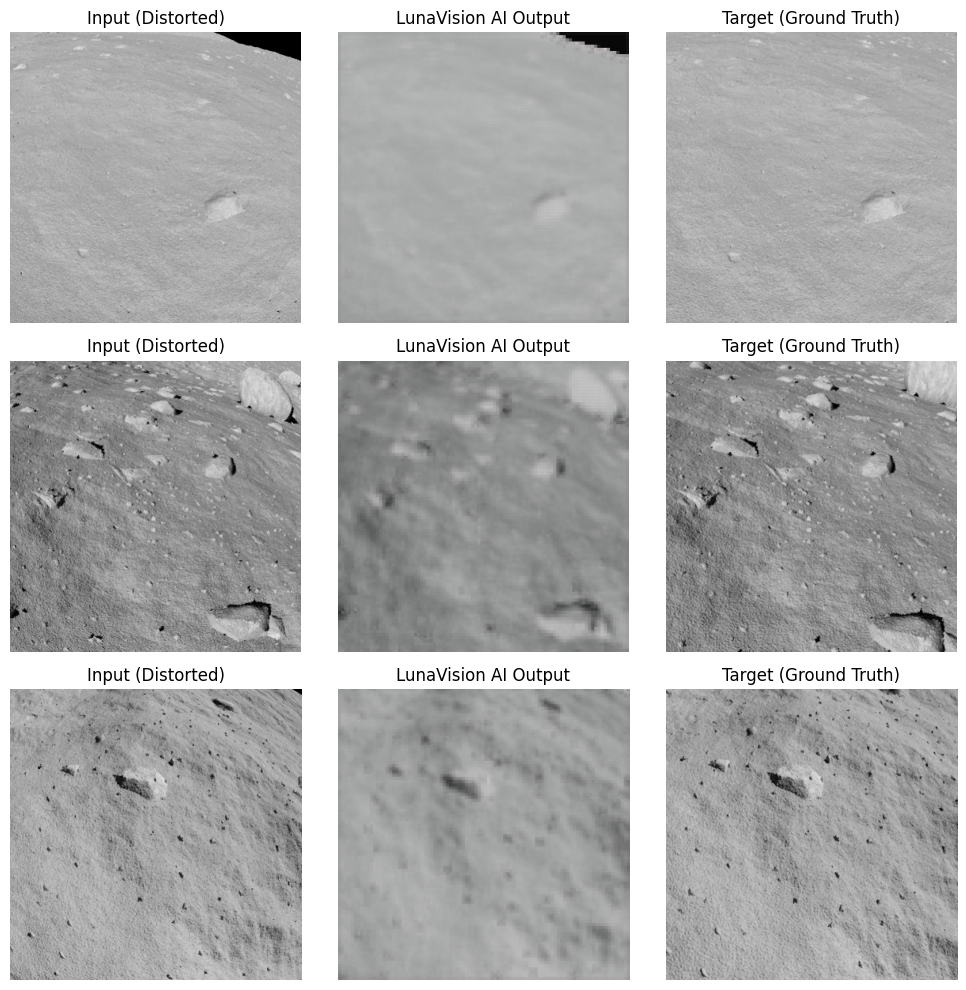

In [41]:
import matplotlib.pyplot as plt

model.eval()  
distorted_batch, clean_batch = next(iter(train_loader))

with torch.no_grad():
    inputs = distorted_batch.to(device)
    reconstructed = model(inputs).cpu()

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i in range(3):
    input_img = distorted_batch[i].permute(1, 2, 0).numpy()
    target_img = clean_batch[i].permute(1, 2, 0).numpy()
    output_img = reconstructed[i].permute(1, 2, 0).numpy()
    
    axes[i, 0].imshow(input_img)
    axes[i, 0].set_title("Input (Distorted)")
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(output_img)
    axes[i, 1].set_title("LunaVision AI Output")
    axes[i, 1].axis("off")
    
    axes[i, 2].imshow(target_img)
    axes[i, 2].set_title("Target (Ground Truth)")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()